In [1]:
import os
import requests
import json
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor


import re

In [2]:
squad_rank_map = {
    # [21-22, 22-23, 23-24, 24-25]
    'Ajaccio': [22, 18, 22, 22], 'Alavés': [20, 22, 10, 12], 'Almería': [22, 17, 19, 22], 'Angers': [14, 20, 22, 18],
    'Arminia': [17, 22, 22, 22], 'Arsenal': [5, 2, 2, 2], 'Aston Villa': [14, 7, 4, 5], 'Atalanta': [8, 5, 4, 3],
    'Athletic Club': [8, 8, 5, 6], 'Atlético Madrid': [3, 3, 4, 3], 'Augsburg': [14, 15, 11, 13], 'Auxerre': [22, 17, 22, 15],
    'Barcelona': [2, 1, 2, 1], 'Bayern Munich': [1, 1, 3, 1], 'Bochum': [13, 14, 16, 17], 'Bologna': [13, 9, 5, 8],
    'Bordeaux': [20, 22, 22, 22],'Bournemouth': [22, 15, 12, 11],'Brentford': [13, 9, 16, 14],'Brest': [11, 14, 3, 9],
    'Brighton': [9, 6, 11, 10],'Burnley': [18, 22, 19, 22],'Cagliari': [18, 22, 16, 16],'Celta Vigo': [11, 13, 14, 11],
    'Chelsea': [3, 12, 6, 4],'Clermont Foot': [17, 8, 18, 22],'Cremonese': [22, 19, 22, 22],'Crystal Palace': [12, 11, 10, 12],
    'Cádiz': [17, 14, 18, 22],'Darmstadt 98': [22, 22, 18, 22],'Dortmund': [2, 2, 5, 4],'Eintracht Frankfurt': [11, 7, 6, 6],
    'Elche': [13, 20, 22, 22],'Empoli': [14, 14, 17, 14],'Espanyol': [14, 19, 22, 17],'Everton': [16, 17, 15, 15],
    'Fiorentina': [7, 8, 8, 7], 'Freiburg': [6, 5, 10, 8], 'Frosinone': [22, 22, 18, 22],
    'Fulham': [22, 10, 13, 12], 'Genoa': [19, 22, 11, 13], 'Getafe': [15, 15, 12, 14], 'Girona': [22, 10, 3, 7],
    'Gladbach': [10, 10, 14, 11], 'Granada': [18, 22, 20, 22], 'Greuther Fürth': [18, 22, 22, 22], 'Heidenheim': [22, 22, 8, 12],
    'Hellas Verona': [9, 18, 13, 15], 'Hertha BSC': [16, 18, 22, 22], 'Hoffenheim': [9, 12, 7, 10], 'Inter': [2, 3, 1, 2],
    'Juventus': [4, 7, 3, 3], 'Köln': [7, 11, 17, 22], 'Las Palmas': [22, 22, 16, 17], 'Lazio': [5, 2, 7, 6],
    'Le Havre': [22, 22, 15, 16], 'Lecce': [22, 16, 14, 15], 'Leeds United': [17, 19, 22, 22], 'Leicester City': [8, 18, 22, 16],
    'Lens': [7, 2, 7, 8], 'Levante': [19, 22, 22, 22], 'Leverkusen': [3, 6, 1, 3], 'Lille': [10, 5, 4, 5],
    'Liverpool': [2, 5, 3, 1], 'Lorient': [16, 10, 19, 22], 'Luton Town': [22, 22, 18, 22], 'Lyon': [8, 7, 6, 6],
    'Mainz 05': [8, 9, 13, 12], 'Mallorca': [16, 9, 15, 13], 'Manchester City': [1, 1, 1, 2], 'Manchester Utd': [6, 3, 8, 7],
    'Marseille': [2, 3, 8, 5], 'Metz': [19, 22, 18, 22], 'Milan': [1, 4, 2, 4], 'Monaco': [3, 6, 2, 2],
    'Montpellier': [13, 12, 12, 14], 'Monza': [22, 11, 12, 15], 'Nantes': [9, 16, 14, 16], 'Napoli': [3, 1, 10, 4],
    'Newcastle United': [11, 4, 7, 6], 'Nice': [5, 9, 5, 6], 'Norwich City': [20, 22, 22, 22], 'Nottingham Forest': [22, 16, 17, 14],
    'Osasuna': [10, 7, 11, 10], 'Paris Saint-Germain': [1, 1, 1, 1], 'RB Leipzig': [4, 3, 4, 4], 'Rayo Vallecano': [12, 11, 17, 15],
    'Real Betis': [5, 6, 7, 7], 'Real Madrid': [1, 2, 1, 2], 'Real Sociedad': [6, 4, 6, 8], 'Reims': [12, 11, 9, 10],
    'Rennes': [4, 4, 10, 9], 'Roma': [6, 6, 6, 7], 'Saint-Étienne': [18, 22, 22, 16], 'Salernitana': [17, 15, 20, 22],
    'Sampdoria': [15, 20, 22, 22], 'Sassuolo': [11, 13, 19, 22], 'Schalke 04': [22, 17, 22, 22], 'Sevilla': [4, 12, 14, 12],
    'Sheffield United': [22, 22, 20, 22], 'Southampton': [15, 20, 22, 19], 'Spezia': [16, 18, 22, 22],'Strasbourg': [6, 15, 13, 13],
    'Stuttgart': [15, 16, 2, 7],'Torino': [10, 10, 9, 11], 'Tottenham Hotspur': [4, 8, 5, 5],'Toulouse': [22, 13, 11, 12],
    'Troyes': [15, 19, 22, 22],'Udinese': [12, 12, 15, 13], 'Union Berlin': [5, 4, 15, 11],'Valencia': [9, 14, 9, 13],
    'Valladolid': [22, 18, 22, 19],'Venezia': [20, 22, 22, 20], 'Villarreal': [7, 5, 8, 6],'Watford': [19, 22, 22, 22],
    'Werder Bremen': [22, 13, 9, 10],'West Ham United': [7, 14, 9, 11], 'Wolfsburg': [12, 8, 12, 12],'Wolves': [10, 13, 14, 15],
}

def get_squad_rank_map(year, full_map=squad_rank_map):
    index = year - 2021
    if (index < 0 or index >= len(full_map)):
        print("No Data For That Year")
        return

    temp_dict = {}
    for squad in full_map:
        temp_dict[squad] = full_map[squad][index]
        
    return temp_dict

In [3]:
def apply_squad_rank(df, year):
    df = df.copy()
    rank_map_for_year = get_squad_rank_map(year)
    
    if rank_map_for_year is None:
        return df

    df['Squad_Rank'] = df['Unnamed: 4_level_0_Squad'].map(rank_map_for_year).apply(lambda x: 21 - x if pd.notnull(x) else 0)
    df = df.drop(columns=['Unnamed: 4_level_0_Squad'])
    
    return df

def clean_dataframe(df):
    df = df.dropna(subset = ["Value (€)"])
    df = df.drop(columns = ["Name_Clean", 
                            "Unnamed: 0_y", 
                            "Name_y", 
                            "Unnamed: 0_x", 
                            "Unnamed: 0_level_0_Rk", 
                            "Unnamed: 24_level_0_Matches",
                            "Unnamed: 0"
                           ])
    df = df.rename(columns={
        'Unnamed: 3_level_0_Pos': 'Position', 
        'Unnamed: 5_level_0_Age': 'Age',
        'Unnamed: 6_level_0_Born': 'Born',
        'Unnamed: 2_level_0_Nation': 'Nationality',
        'Playing Time_MP': 'Match Played',
        'Name_x': 'Name',
        'Playing Time_Starts': 'Match Started',
        'Playing Time_Min': 'Minutes Played',
        'Playing Time_90s': 'Minutes Played / 90',
        'Performance_Gls': 'Goals',
        'Performance_Ast': 'Assists',
        'Performance_G+A': 'Goals + Assists',
        'Performance_G-PK': 'Non-Penality Goals',
        'Performance_PK': 'Penalty Kick Goals',
        'Performance_PKatt': 'Penalty Kick Attempted',
        'Performance_CrdY': 'Yellow Cards',
        'Performance_CrdR': 'Red Cards',
        'Per 90 Minutes_Gls': 'Goals Per 90 Minutes',
        'Per 90 Minutes_Ast': 'Assists Per 90 Minutes',
        'Per 90 Minutes_G+A': 'G+A Per 90 Minutes',
        'Per 90 Minutes_G-PK': 'Non-Penality Goals Per 90 Minutes',
        'Per 90 Minutes_G+A-PK': 'Non-Penalty Goals + Assists/90',
        'Value (€)': 'Value',
        # '': '',
        # '': '',
        # '': '',
        # '': '',
        # '': '',
        # '': '',
    })

    intger_column_list = ["Age", "Born", "Match Played", "Match Started", "Minutes Played", "Goals", "Assists", "Goals + Assists", 
                  "Non-Penality Goals", "Penalty Kick Goals", "Penalty Kick Attempted", "Yellow Cards", "Red Cards"]
    
    float_column_list = ["Minutes Played / 90", "Goals Per 90 Minutes", "Assists Per 90 Minutes", 
                  "G+A Per 90 Minutes", "Non-Penality Goals Per 90 Minutes", "Non-Penalty Goals + Assists/90"]

    numeric_column_list = []
    numeric_column_list.extend(intger_column_list)
    numeric_column_list.extend(float_column_list)

    for column in numeric_column_list:
        df[column] = pd.to_numeric(df[column], errors='coerce')
    
    return df

def divide_position(df):
    position_dummies = df['Position'].str.get_dummies(sep=',')
    return pd.concat([df, position_dummies], axis=1)  

def preprocess_dataframe(df):
    df = df.copy()

    df_rest = df.drop(columns=["Value"])
    
    scaler = StandardScaler()
    numeric_cols = df_rest.select_dtypes(include=['float64', 'int64']).columns
    scaler.fit(df[numeric_cols])
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    df = divide_position(df)
    df = df.set_index('Name')
    df = df.drop(columns = ["Nationality", "Born", "Position"])

    df = df[[c for c in df.columns if c != "Value"] + ["Value"]]
    return df, scaler

def end_to_end_process_data(df, year):
    df = apply_squad_rank(df, year)
    df = clean_dataframe(df)
    df, _ = preprocess_dataframe(df)
    return df

def end_to_end_load_data(filename):
    df = pd.read_csv(filename)
    year = int("".join(re.findall(r'\d+', filename)))

    df = end_to_end_process_data(df, year)

    return df

In [4]:
folder_path = "Datasets"

test_2024 = end_to_end_load_data(os.path.join(folder_path, "test_2024.csv"))
train_2023 = end_to_end_load_data(os.path.join(folder_path, "train_2023.csv"))
train_2022 = end_to_end_load_data(os.path.join(folder_path, "train_2022.csv"))
train_2021 = end_to_end_load_data(os.path.join(folder_path, "train_2021.csv"))

In [5]:
df = pd.concat([train_2023,train_2022,train_2021], axis=0)

In [6]:
df.head(20)

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Squad_Rank,DF,FW,GK,MF,Value
Name,,,,,,,,,,,,,,,,,,,,,,,,
Max Aarons,-0.437777,-0.099153,-0.231747,-0.163884,-0.168218,-0.583867,-0.228751,-0.506345,-0.601973,-0.229411,-0.249439,-0.712266,-0.359094,-0.546338,-0.122461,-0.480484,-0.531729,-0.468174,-0.512440,1,0,0,0,6000000.0
Tyler Adams,-0.206563,-1.645103,-1.310370,-1.343525,-1.347807,-0.583867,-0.696572,-0.703822,-0.601973,-0.229411,-0.249439,-1.075944,-0.359094,-0.546338,-0.519580,-0.703702,-0.531729,-0.697884,-0.512440,0,0,0,1,18000000.0
Tosin Adarabioyo,0.024652,-0.099153,0.217679,0.237785,0.240833,-0.021132,-0.696572,-0.308869,0.032314,-0.229411,-0.249439,-0.348588,-0.359094,-0.081517,-0.519580,-0.352931,-0.049336,-0.336912,-0.698995,1,0,0,0,20000000.0
Simon Adingra,-0.900206,0.901167,0.846876,0.877285,0.878192,1.104337,-0.228751,0.678515,1.300887,-0.229411,-0.249439,0.015090,-0.359094,0.467818,-0.292655,0.189169,0.520766,0.220954,-0.325884,0,0,0,1,28000000.0
Nayef Aguerd,0.487080,-0.008215,0.487335,0.491471,0.488166,-0.302499,-0.696572,-0.506345,-0.284829,-0.229411,-0.249439,0.015090,2.322141,-0.335056,-0.519580,-0.544261,-0.312459,-0.533806,0.047227,1,0,0,0,18000000.0
Naouirou Ahamada,-0.900206,-0.099153,-1.400255,-1.102523,-1.100474,-0.583867,-0.696572,-0.703822,-0.601973,-0.229411,-0.249439,0.378767,2.322141,-0.546338,-0.519580,-0.703702,-0.531729,-0.697884,-0.139329,0,0,0,1,3500000.0
Ola Aina,0.255866,0.082723,0.397449,0.317062,0.316936,-0.302499,-0.228751,-0.308869,-0.284829,-0.229411,-0.249439,0.015090,-0.359094,-0.335056,-0.235923,-0.352931,-0.312459,-0.336912,-1.445217,1,0,0,1,22000000.0
Rayan Aït-Nouri,-0.668992,1.083044,1.206417,0.990387,0.992345,-0.021132,-0.228751,-0.111392,0.032314,-0.229411,-0.249439,1.469801,-0.359094,-0.208286,-0.292655,-0.321043,-0.180898,-0.304096,-0.885551,1,0,0,1,35000000.0
Kristoffer Ajer,0.024652,0.628352,0.487335,0.465046,0.469141,-0.021132,-0.228751,-0.111392,0.032314,-0.229411,-0.249439,0.742445,-0.359094,-0.123773,-0.235923,-0.225378,-0.093190,-0.205649,-1.258662,1,0,0,0,18000000.0


In [7]:

X, y = df.drop(columns = ["Value"]), df["Value"]
X_train, _, y_train, _ = train_test_split(X, y, random_state=42)

X_test, y_test = test_2024.drop(columns = ["Value"]), test_2024["Value"]

In [8]:
# model = LinearRegression()
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test) 

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared (R2) Score: {r2}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

R-squared (R2) Score: 0.6100346118370443
Mean Absolute Error (MAE): 8016639.848710264
Mean Squared Error (MSE): 174183650751458.1
Root Mean Squared Error (RMSE): 13197865.386169769


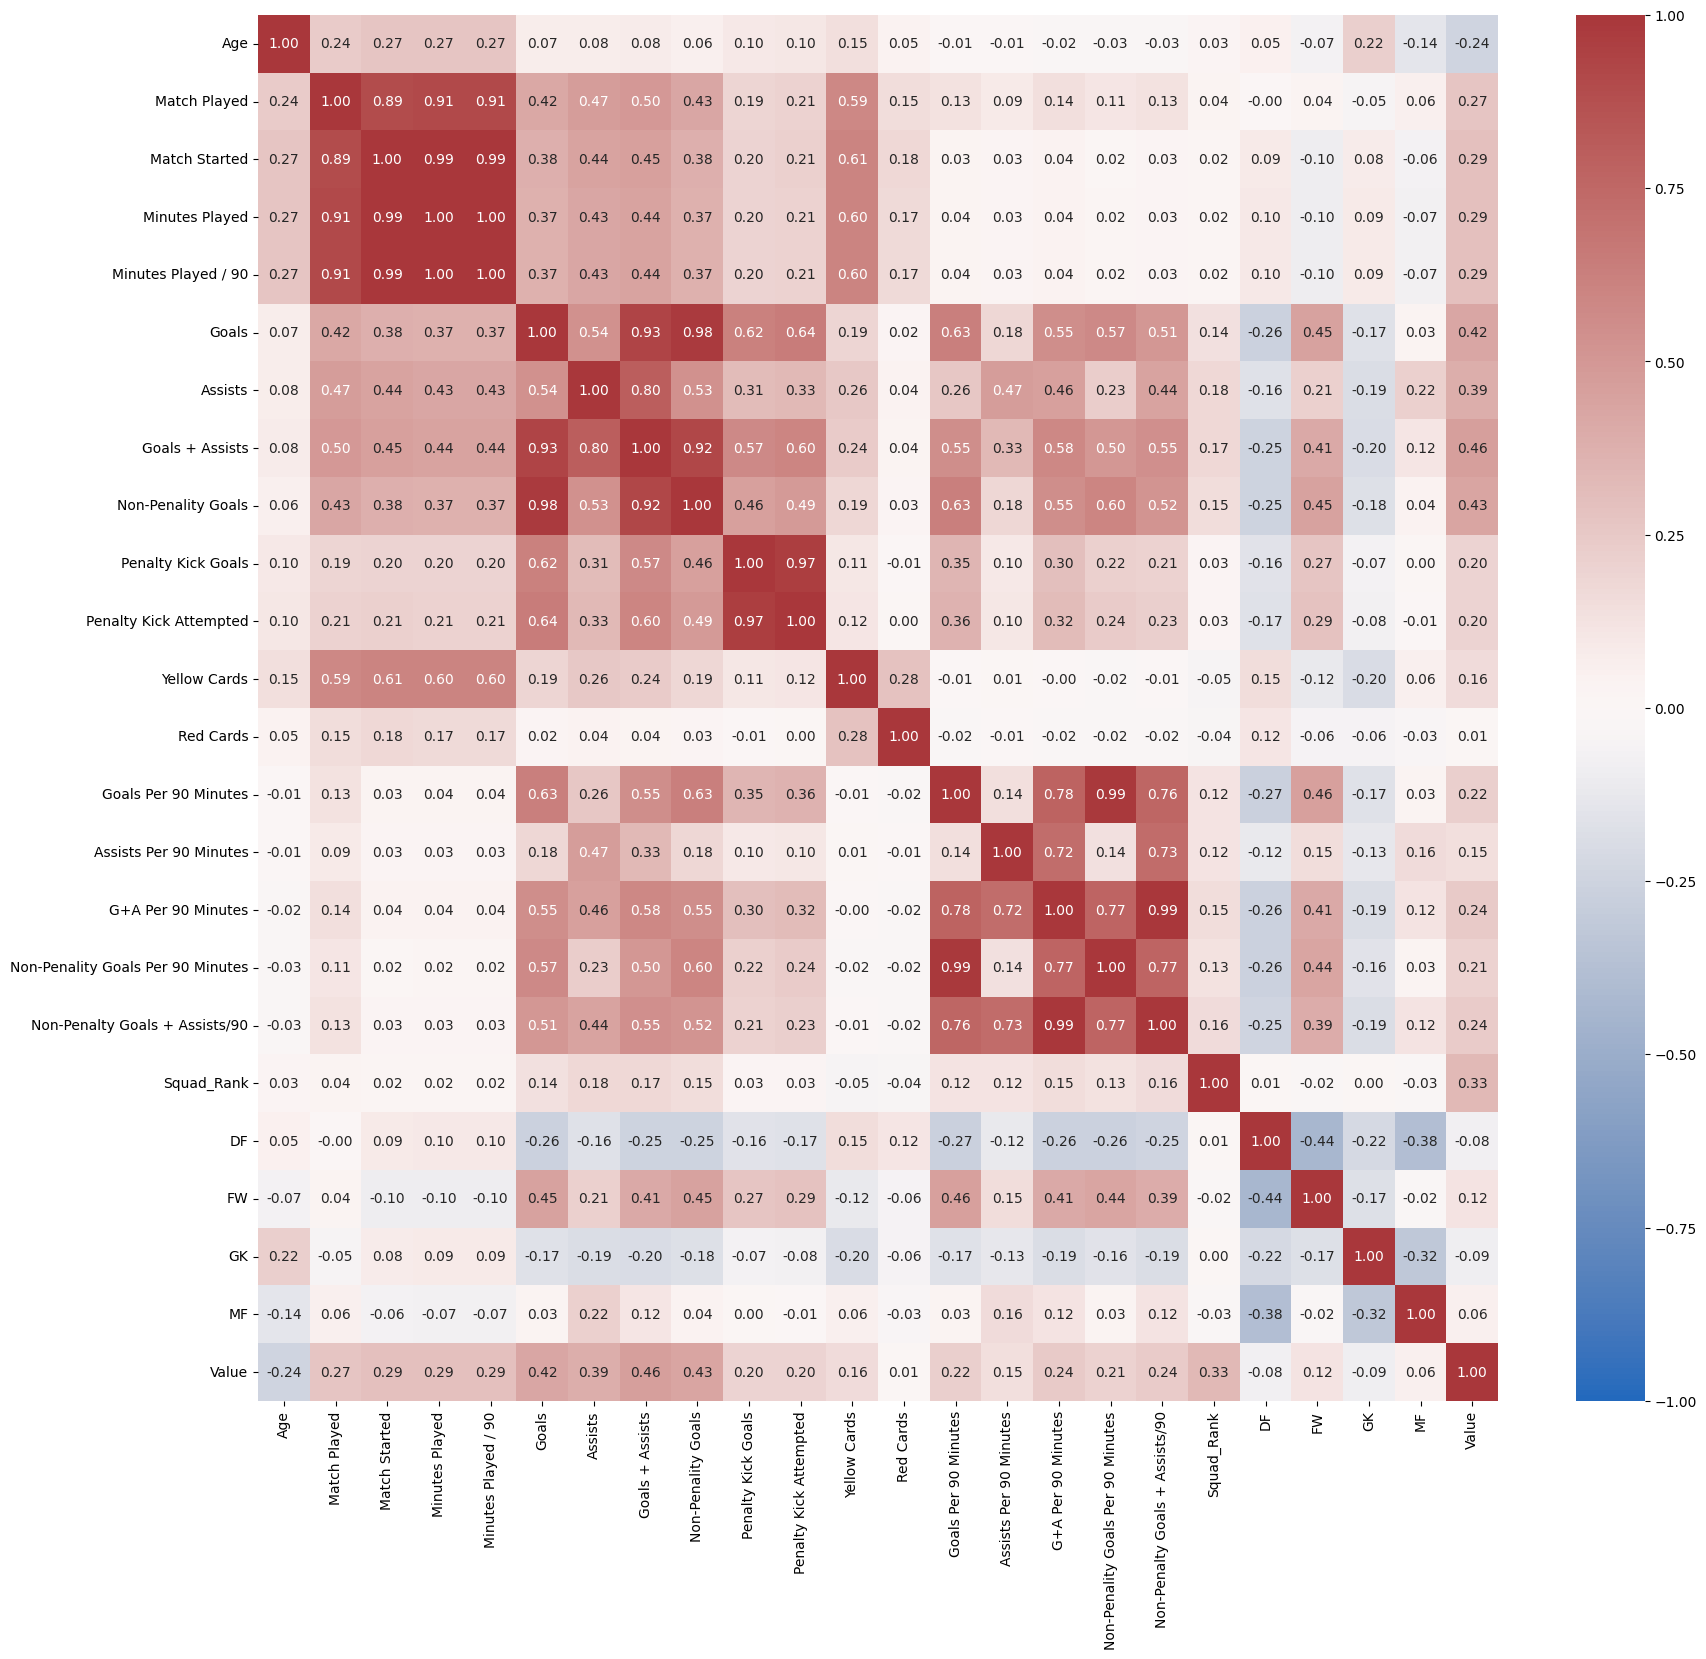

In [9]:
correlation_matrix = df.corr()

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='vlag', vmin=-1, vmax=1)
plt.show()

In [10]:
comp = pd.DataFrame({
    "true": y_test,
    "pred": y_pred
})
comp["error"] = comp["true"] - comp["pred"] # -x : 과대평가, +x : 과소평가

comp['true'] = comp['true'].apply(lambda x: f"{x:.6e}")

In [11]:
comp.sort_values(by="error")

,true,pred,error
Name,,,
Mika Biereth,2.200000e+07,7.699479e+07,-5.499479e+07
Eliesse Ben Seghir,2.400000e+07,7.476072e+07,-5.076072e+07
Bradley Barcola,7.000000e+07,1.205067e+08,-5.050667e+07
Christian Mawissa,1.500000e+07,5.818803e+07,-4.318803e+07
Lamine Camara,3.000000e+07,6.756091e+07,-3.756091e+07
...,...,...,...
Rodri,7.500000e+07,3.527826e+06,7.147217e+07
Lamine Yamal,2.000000e+08,1.079400e+08,9.206000e+07
Kylian Mbappé,2.000000e+08,9.984315e+07,1.001569e+08


In [12]:
test_2024.loc["Mika Biereth"]

Age                                 -9.621785e-01
Match Played                        -5.600979e-01
Match Started                       -4.536793e-02
Minutes Played                      -2.567005e-01
Minutes Played / 90                 -2.608778e-01
Goals                                2.957121e+00
Assists                              2.075892e-01
Goals + Assists                      2.174216e+00
Non-Penality Goals                   3.109501e+00
Penalty Kick Goals                   1.030040e+00
Penalty Kick Attempted               1.930723e+00
Yellow Cards                        -1.092161e+00
Red Cards                           -3.508416e-01
Goals Per 90 Minutes                 3.960574e+00
Assists Per 90 Minutes               5.097103e-01
G+A Per 90 Minutes                   3.262543e+00
Non-Penality Goals Per 90 Minutes    3.899375e+00
Non-Penalty Goals + Assists/90       3.212596e+00
Squad_Rank                           1.372806e+00
DF                                   0.000000e+00


In [13]:
round(pd.DataFrame(comp["error"]).describe(), 2)

,error
count,1.730000e+03
mean,9.783739e+05
std,1.316536e+07
min,-5.499479e+07
25%,-5.117708e+06
50%,-1.099680e+06
75%,4.226041e+06
max,1.109879e+08


In [14]:
def plot_distribution(df, column_name, figsize=(10, 6), color='lightskyblue', discrete=False, ax=None, show_count=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.histplot(df[column_name], kde=True, color=color, discrete=discrete, ax=ax)
    ax.set_title(f'{column_name} distribution', fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

    data = df[column_name].dropna()
    d_min = data.min()
    d_mean = data.mean()
    d_max = data.max()

    ax.axvline(d_min, color='red', linestyle='--', linewidth=1, label=f'Min: {d_min:.1f}', alpha=0)
    ax.axvline(d_mean, color='black', linestyle='-', linewidth=2, label=f'Mean: {d_mean:.1f}', alpha=0.3)
    ax.axvline(d_max, color='blue', linestyle='--', linewidth=1, label=f'Max: {d_max:.1f}', alpha=0)

    ax.legend()

    if show_count:
        ax.bar_label(ax.containers[0], label_type='edge', padding=3, fontsize=6)
    
    heights = [p.get_height() for p in ax.patches]
    if heights:
        max_height = max(heights)
        ax.set_ylim(0, max_height * 1.1)

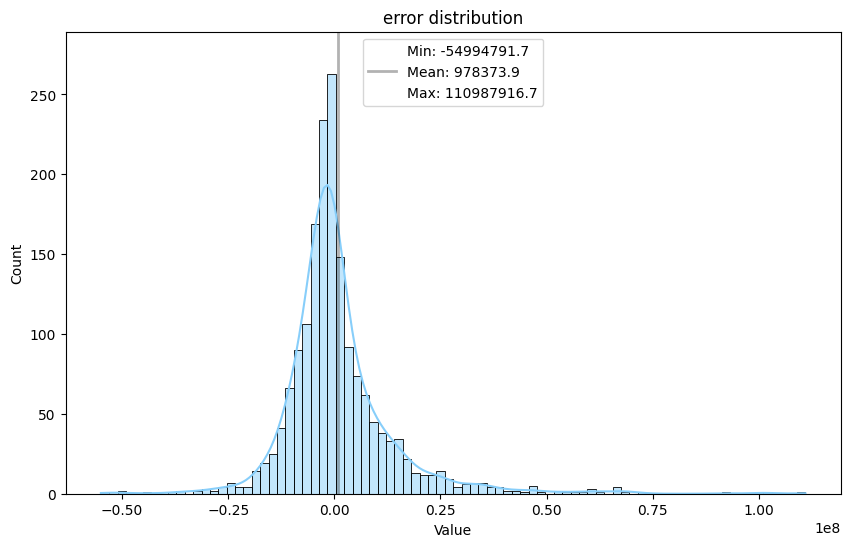

In [15]:
plot_distribution(comp, "error")

In [16]:
round(pd.DataFrame(y_test).describe(), 2)

,Value
count,1.730000e+03
mean,1.593610e+07
std,2.114055e+07
min,5.000000e+04
25%,3.000000e+06
50%,8.000000e+06
75%,2.000000e+07
max,2.000000e+08


In [17]:
round(pd.DataFrame(y_pred).describe(), 2)

,0
count,1.730000e+03
mean,1.495772e+07
std,1.456323e+07
min,1.951516e+05
25%,5.320022e+06
50%,1.078341e+07
75%,1.951156e+07
max,1.205067e+08


In [18]:
round(df.describe(), 2)

,Age,Match Played,Match Started,Minutes Played,Minutes Played / 90,Goals,Assists,Goals + Assists,Non-Penality Goals,Penalty Kick Goals,Penalty Kick Attempted,Yellow Cards,Red Cards,Goals Per 90 Minutes,Assists Per 90 Minutes,G+A Per 90 Minutes,Non-Penality Goals Per 90 Minutes,Non-Penalty Goals + Assists/90,Squad_Rank,DF,FW,GK,MF,Value
count,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5613.00,5.613000e+03
mean,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.36,0.26,0.08,0.55,1.352680e+07
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.48,0.44,0.27,0.50,1.948022e+07
min,-2.33,-1.83,-1.40,-1.47,-1.47,-0.59,-0.70,-0.70,-0.61,-0.25,-0.26,-1.08,-0.36,-0.63,-0.60,-0.78,-0.62,-0.77,-2.04,0.00,0.00,0.00,0.00,5.000000e+04
25%,-0.71,-0.81,-0.95,-0.92,-0.91,-0.58,-0.68,-0.69,-0.60,-0.25,-0.26,-0.71,-0.36,-0.55,-0.52,-0.55,-0.53,-0.54,-0.83,0.00,0.00,0.00,0.00,2.500000e+06
50%,-0.02,0.17,-0.05,-0.03,-0.03,-0.31,-0.23,-0.31,-0.29,-0.24,-0.26,-0.33,-0.34,-0.38,-0.30,-0.30,-0.36,-0.28,0.08,0.00,0.00,0.00,1.00,6.000000e+06
75%,0.67,0.87,0.86,0.82,0.82,0.24,0.24,0.27,0.05,-0.23,-0.25,0.68,-0.33,0.21,0.19,0.32,0.21,0.29,0.80,1.00,1.00,0.00,1.00,1.800000e+07
max,3.68,1.54,2.02,2.14,2.14,9.69,7.35,8.25,9.23,13.22,12.05,4.46,7.68,18.47,36.01,27.09,19.20,27.62,1.54,1.00,1.00,1.00,1.00,2.000000e+08


In [19]:
test_2024_raw = pd.read_csv(os.path.join(folder_path, "test_2024.csv"))

In [20]:
test_2024_raw[test_2024_raw["Name_x"] == "Mika Biereth"]

,Unnamed: 0,Unnamed: 0_x,Unnamed: 0_level_0_Rk,Name_x,Unnamed: 2_level_0_Nation,Unnamed: 3_level_0_Pos,Unnamed: 4_level_0_Squad,Unnamed: 5_level_0_Age,Unnamed: 6_level_0_Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,Performance_Gls,Performance_Ast,Performance_G+A,Performance_G-PK,Performance_PK,Performance_PKatt,Performance_CrdY,Performance_CrdR,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Unnamed: 24_level_0_Matches,Name_Clean,Unnamed: 0_y,Name_y,Value (€)
1291,1291,1291,69,Mika Biereth,dk DEN,FW,Monaco,21,2003,16,16,1228,13.6,13,2,15,12,1,2,0,0,0.95,0.15,1.10,0.88,1.03,Matches,mika biereth,2154.0,Mika Biereth,22000000.0


In [ ]:
models_evaluation

In [21]:
models = {
    # "Baseline (Mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": linear_model.LinearRegression(),
    "Ridge Regression": linear_model.Ridge(alpha=1.0),
    "Lasso Regression": linear_model.Lasso(alpha=0.001),
    "ElasticNet": linear_model.ElasticNet(alpha=0.001, l1_ratio=0.5),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR (RBF)": SVR(kernel="rbf", C=10, epsilon=0.1)
}

models_evaluation = {}
for model_name in models:
    model = models[model_name]
    model_info = {}

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    model_info["y_pred"] = y_pred
    
    r2 = model.score(X_test, y_test) 
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    model_info["metrics"] = [r2, mae, mse, rmse]

    models_evaluation[model_name] = model_info

/Users/juhyeongpang/Desktop/Projects/LikeLions/S26/.scouter_venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.667e+17, tolerance: 1.617e+14
  model = cd_fast.enet_coordinate_descent(
/Users/juhyeongpang/Desktop/Projects/LikeLions/S26/.scouter_venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.673e+17, tolerance: 1.617e+14
  model = cd_fast.enet_coordinate_descent(


In [22]:
def print_models_evalutation(models_evaluation):

    for model in models_evaluation:
        metrics = models_evaluation[model]["metrics"]
        y_pred = models_evaluation[model]["y_pred"]

        print(f"{model} : ")


        r2, mae, mse, rmse = metrics[0], metrics[1], metrics[2], metrics[3]

        plt.figure(figsize=(10, 5))
        sns.histplot(y_test, kde=True, color='skyblue', label='Actual (y_test)', alpha=0.5)
        sns.histplot(y_pred, kde=True, color='red', label=f'Predicted ({model})', alpha=0.5)
        plt.title(f'Comparison of Actual vs Predicted Distribution ({model})')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend(loc='upper right')
        plt.show()

        print(f"    - R2: {r2}")
        print(f"    - MAE: {mae}")
        print(f"    - MSE: {mse}")
        print(f"    - RMSE: {rmse}")
        print()

Linear Regression : 


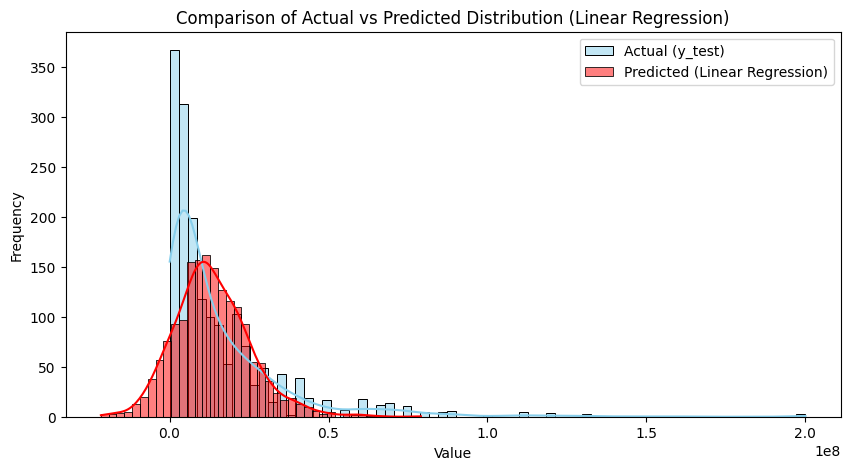

    - R2: 0.43060017234650616
    - MAE: 9686289.349116301
    - MSE: 254330624533508.6
    - RMSE: 15947746.691414075

Ridge Regression : 


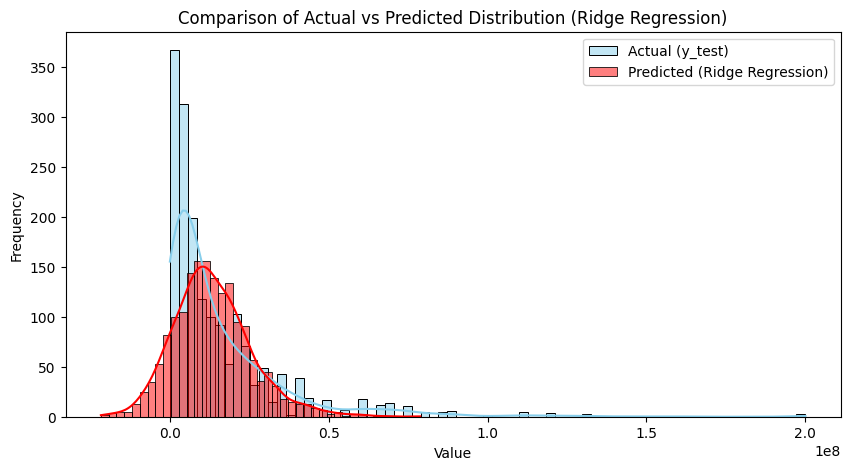

    - R2: 0.44466531447742674
    - MAE: 9600503.43225093
    - MSE: 248048226456481.97
    - RMSE: 15749546.865115896

Lasso Regression : 


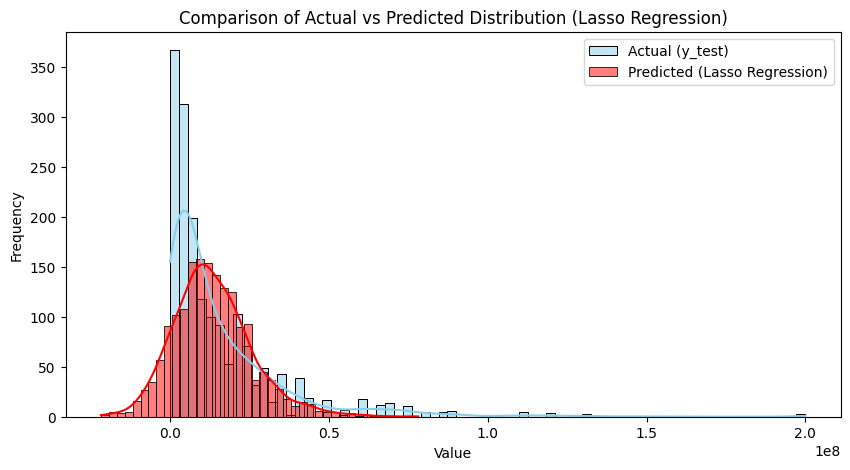

    - R2: 0.4450657784234061
    - MAE: 9605887.859691799
    - MSE: 247869353473847.22
    - RMSE: 15743867.170230038

ElasticNet : 


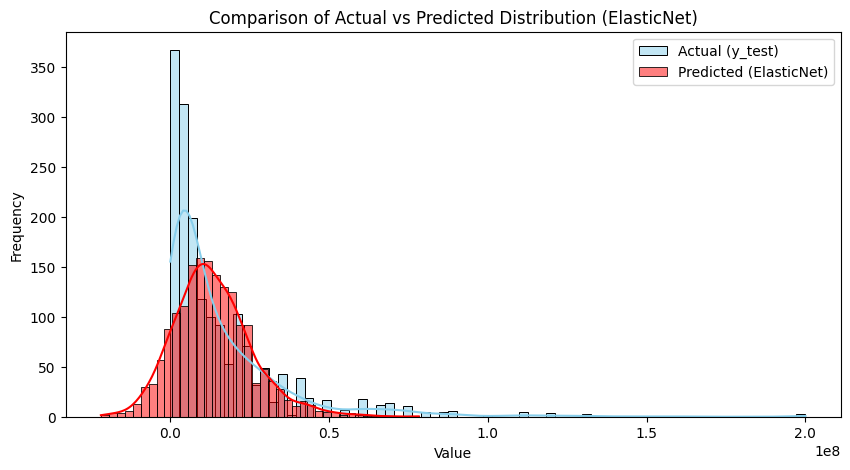

    - R2: 0.4454981570165606
    - MAE: 9598834.955966914
    - MSE: 247676225354920.53
    - RMSE: 15737732.53537245

KNN Regressor : 


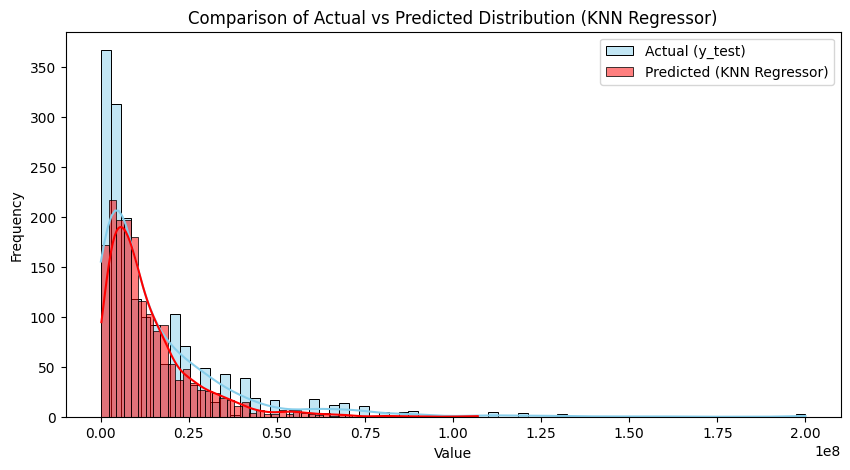

    - R2: 0.43288838532902596
    - MAE: 9051841.040462427
    - MSE: 253308561286127.16
    - RMSE: 15915670.305900633

Random Forest : 


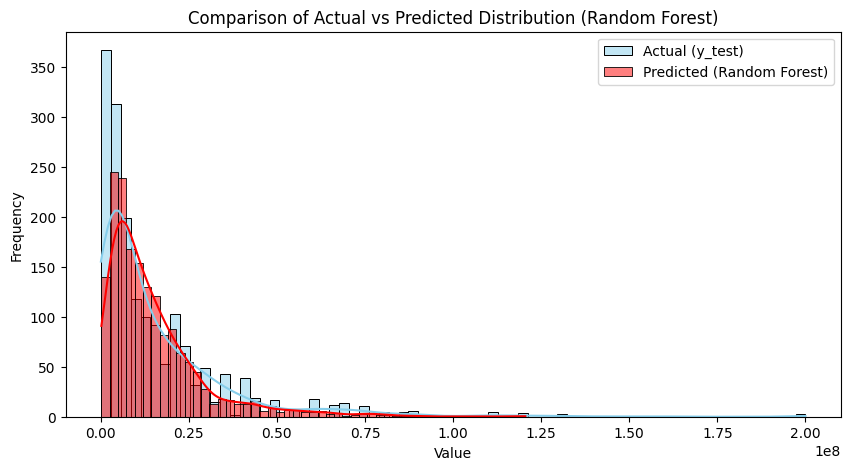

    - R2: 0.6100346118370443
    - MAE: 8016639.848710264
    - MSE: 174183650751458.1
    - RMSE: 13197865.386169769

Gradient Boosting : 


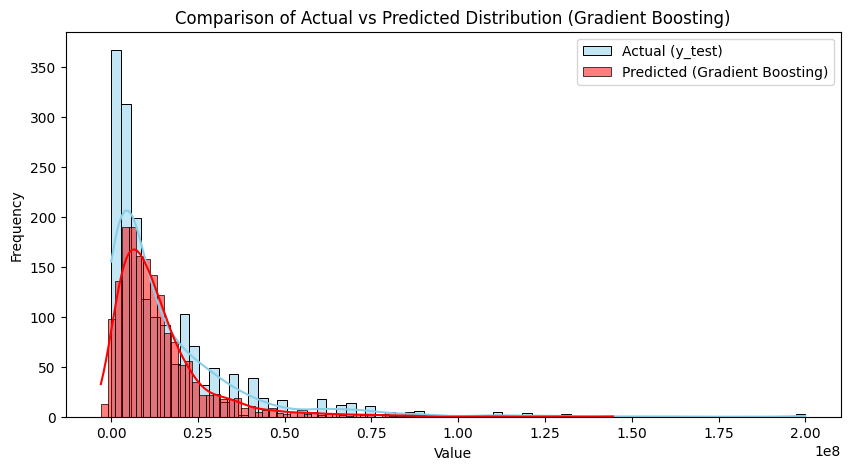

    - R2: 0.5943577139436065
    - MAE: 7767830.495762545
    - MSE: 181185962726888.53
    - RMSE: 13460533.523114473

SVR (RBF) : 


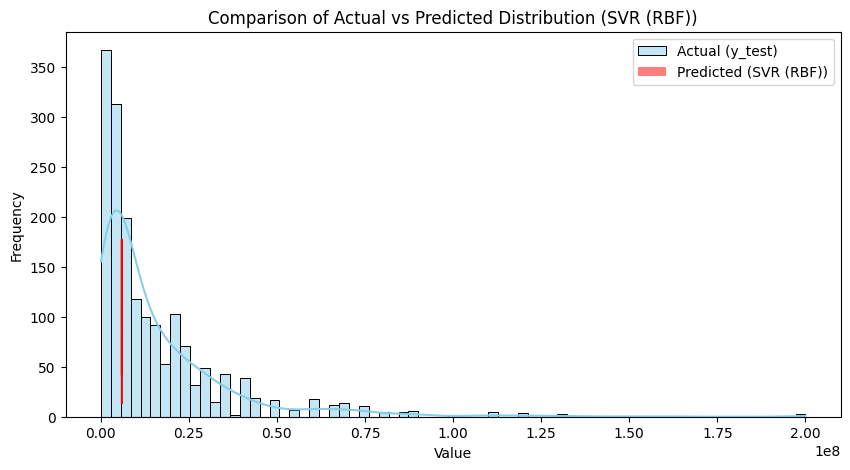

    - R2: -0.22090589741698352
    - MAE: 12584413.685663668
    - MSE: 545335183304037.06
    - RMSE: 23352412.794057



In [23]:
print_models_evalutation(models_evaluation)